# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Loading the Dataset

In [2]:
url = "https://raw.githubusercontent.com/Bumb1eBee20/ExcelR---Data-Science-Assignments-Submissions/5bc18eed4ece95d54af5a8e7a2993a91cb47a17e/14.%20PCA/data/wine.csv"
df = pd.read_csv(url)

# Preview of the Dataset

In [3]:
df

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


# Initial Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


## Dimensions of the Dataset

In [5]:
print("Shape :",df.shape)
print("Size : ",df.size)

Shape : (178, 14)
Size :  2492


## Checking DataTypes

In [6]:
df.dtypes

,0
Type,int64
Alcohol,float64
Malic,float64
Ash,float64
Alcalinity,float64
Magnesium,int64
Phenols,float64
Flavanoids,float64
Nonflavanoids,float64
Proanthocyanins,float64


## Observation :

The dataset contains 178 rows and 14 columns, with a total of 2,492 values. All columns have 178 non-null values, indicating that there are no missing values in the dataset. The features are primarily numerical, consisting of 11 float64 columns and 3 int64 columns. The `Type` column is stored as an integer but represents a categorical class/target variable, so it may be treated as a categorical variable during analysis and modeling

# Data Cleaning

## Checking Duplicate Records and Missing Values

In [7]:
print("No.of Duplicate Records : ",df.duplicated().sum())
print("="*50)
print("NO.of Null Values : ")
print(df.isnull().sum())

No.of Duplicate Records :  0
NO.of Null Values : 
Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64


## Checking Target Variable `Type`

In [8]:
df["Type"].value_counts(ascending=False)

,count
Type,
2,71
1,59
3,48


## Observation :

The dataset contains no duplicate records and no missing values, indicating good data quality. The target variable `Type` has three classes, with Class 2 having the highest number of records (71), followed by Class 1 (59) and Class 3 (48). The class distribution is relatively balanced, although Class 3 has slightly fewer observations than the other classes.

# Descriptive Statistics

In [9]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [10]:
print("Mode : ")
print(df.mode().iloc[0])

Mode : 
Type                 2.00
Alcohol             12.37
Malic                1.73
Ash                  2.28
Alcalinity          20.00
Magnesium           88.00
Phenols              2.20
Flavanoids           2.65
Nonflavanoids        0.26
Proanthocyanins      1.35
Color                2.60
Hue                  1.04
Dilution             2.87
Proline            520.00
Name: 0, dtype: float64


## Observation :

The dataset contains **178 observations** across all variables, confirming that there are no missing values. Most features show noticeable variation in their ranges and standard deviations. `Proline` and `Magnesium` have particularly large ranges and variability compared to other variables, suggesting that **feature scaling may be required before applying distance-based or scale-sensitive machine learning algorithms**. Additionally, differences between the mean, median, and mode in some variables indicate possible **skewness or the presence of outliers**, which can be further examined using histograms and boxplots. The `Type` column represents the categorical target variable with three classes and should not be interpreted as a continuous numerical feature.


# Exploratory Data Analysis

In [11]:
numerical_cols = df.drop(columns="Type").columns
print(numerical_cols)

Index(['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')


## Boxplot Analysis

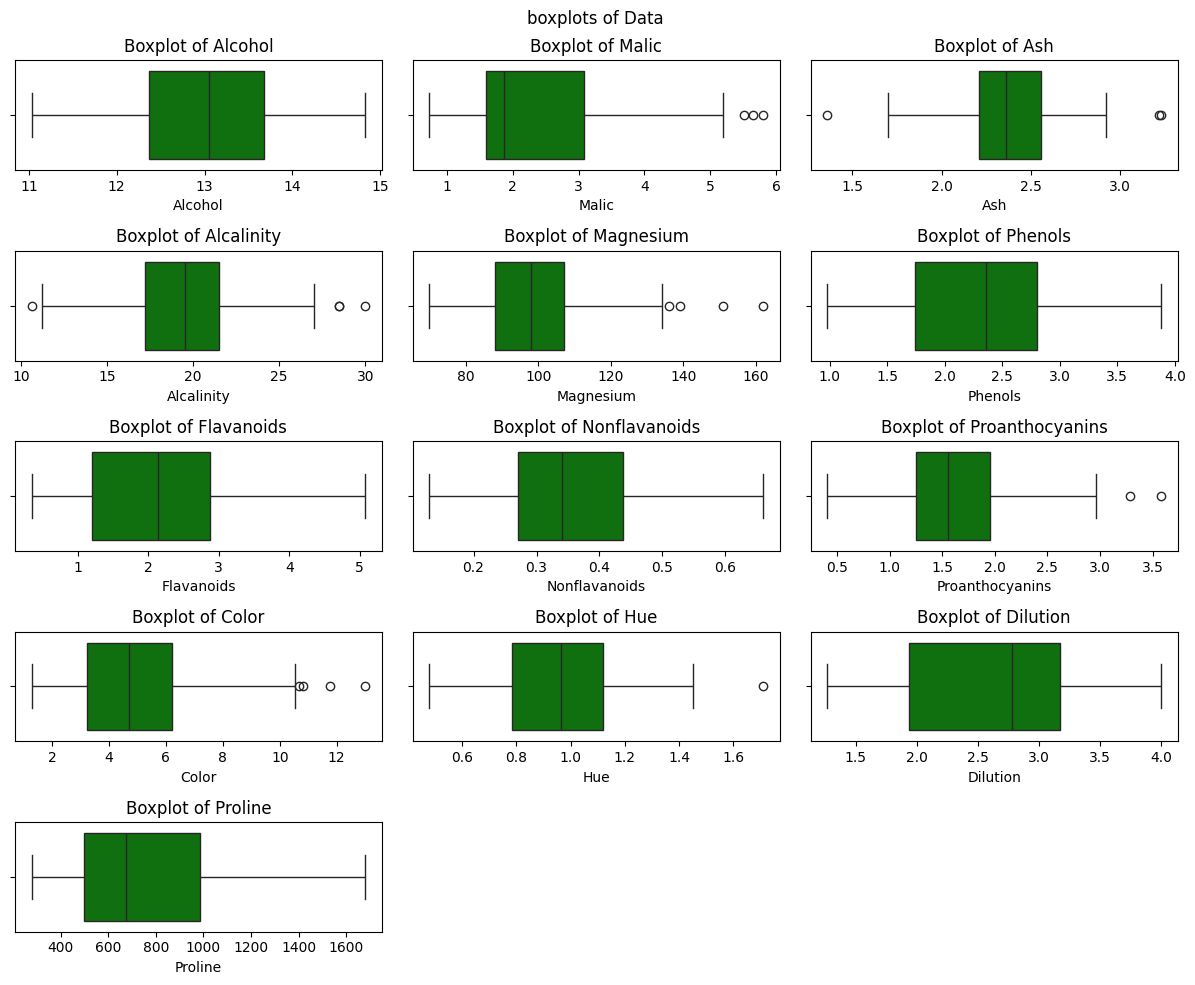

In [12]:
fig,ax = plt.subplots(5,3,figsize=(12,10))

for axis,col in zip(ax.flat,numerical_cols):
  sns.boxplot(data = df,x=col,ax=axis,color="green")
  axis.set_title(f"Boxplot of {col}")
  axis.set_xlabel(col)

for axis in ax.flat[len(numerical_cols):]:
  axis.remove()

plt.suptitle("boxplots of Data")
plt.tight_layout()
plt.show()

### Observation :

Most numerical features show a reasonable spread, but several variables contain potential outliers.

- **Malic, Ash, Alcalinity, Magnesium, Proanthocyanins, Color, and Hue** show noticeable outliers.
- **Alcohol, Phenols, Flavanoids, Nonflavanoids, Dilution, and Proline** do not show significant outliers.
- Features such as **Color, Proline, and Magnesium** have relatively large ranges and variability.
- Further outlier treatment may be considered depending on the machine learning model used.

## Histogram Analysis

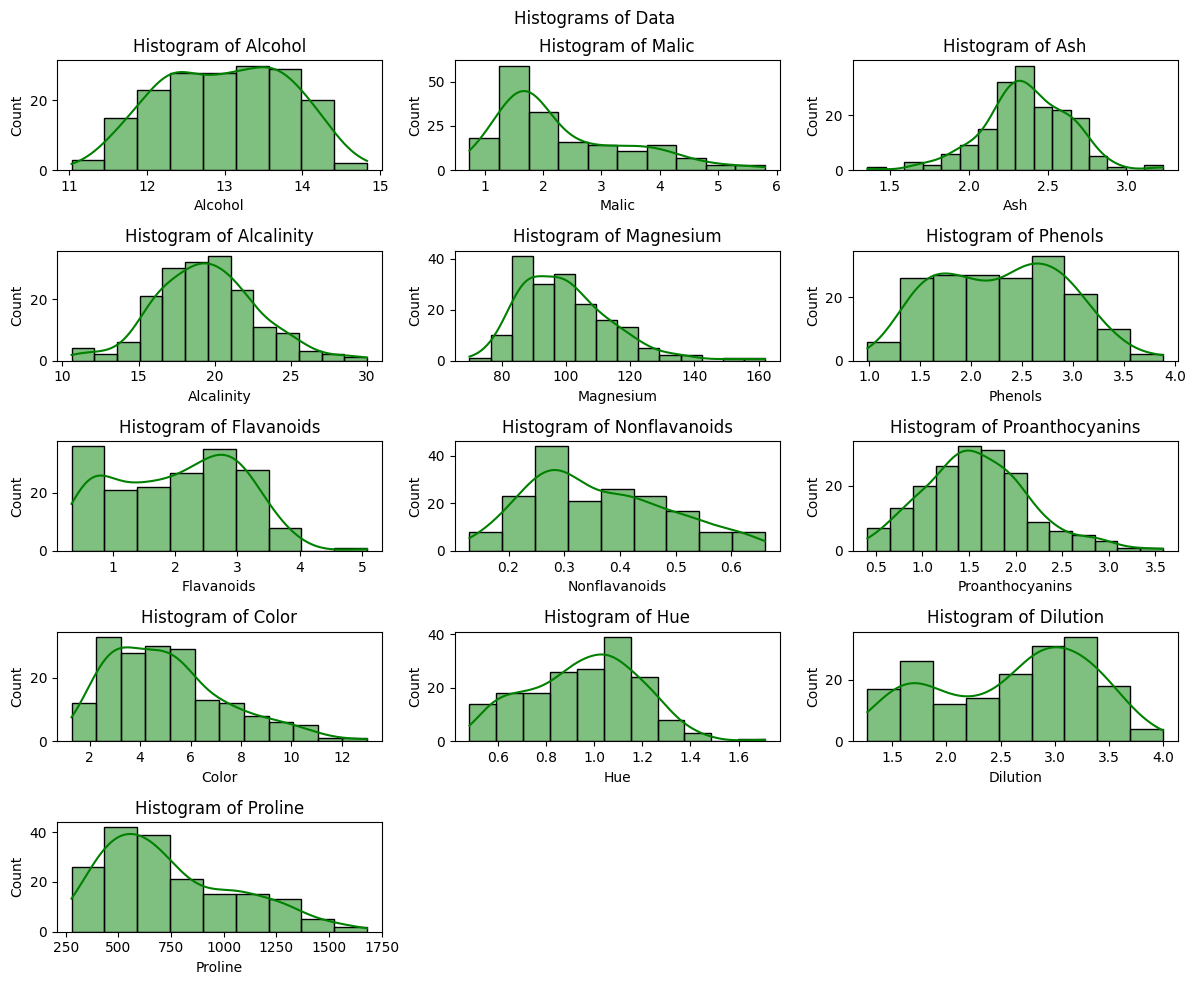

In [13]:
fig,ax = plt.subplots(5,3,figsize=(12,10))

for axis,col in zip(ax.flat,numerical_cols):
  sns.histplot(data = df,x=col,ax=axis,color="green",kde=True)
  axis.set_title(f"Histogram of {col}")
  axis.set_xlabel(col)

for axis in ax.flat[len(numerical_cols):]:
  axis.remove()

plt.suptitle("Histograms of Data")
plt.tight_layout()
plt.show()

### Observation :

The distributions of the numerical variables vary considerably.

- **Alcohol and Ash** appear relatively close to a normal distribution.
- **Malic, Magnesium, Color, and Proline** show noticeable right-skewness.
- **Phenols, Flavanoids, Hue, and Dilution** show possible multiple peaks, suggesting potential subgroup differences.
- Some variables have skewed distributions, which may influence models that assume normally distributed features.

## Countplot Analysis

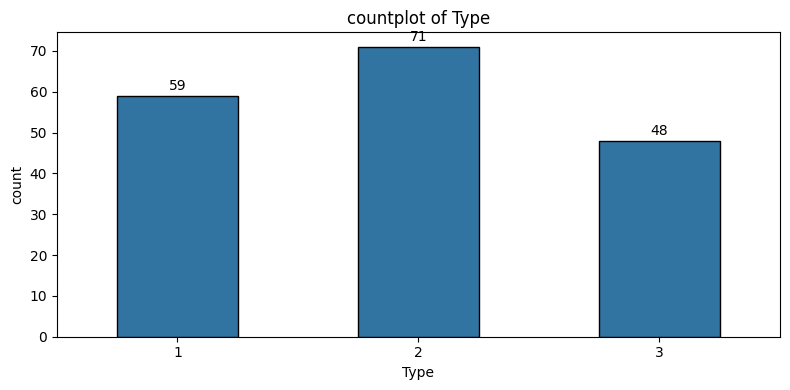

In [14]:
fig,ax = plt.subplots(figsize=(8,4))

sns.countplot(data=df,x="Type",ax=ax,edgecolor="Black",width=0.5)
ax.set_title("countplot of Type")
ax.set_xlabel("Type")

for container in ax.containers:
  ax.bar_label(container,padding=2)
plt.tight_layout()
plt.show()

### Observation :

The target variable **Type** contains three classes:

- **Type 1:** 59 records
- **Type 2:** 71 records
- **Type 3:** 48 records

The classes are relatively balanced, although **Type 2** has the highest number of observations and **Type 3** has the lowest. There is no severe class imbalance.

## Densityplot Analysis

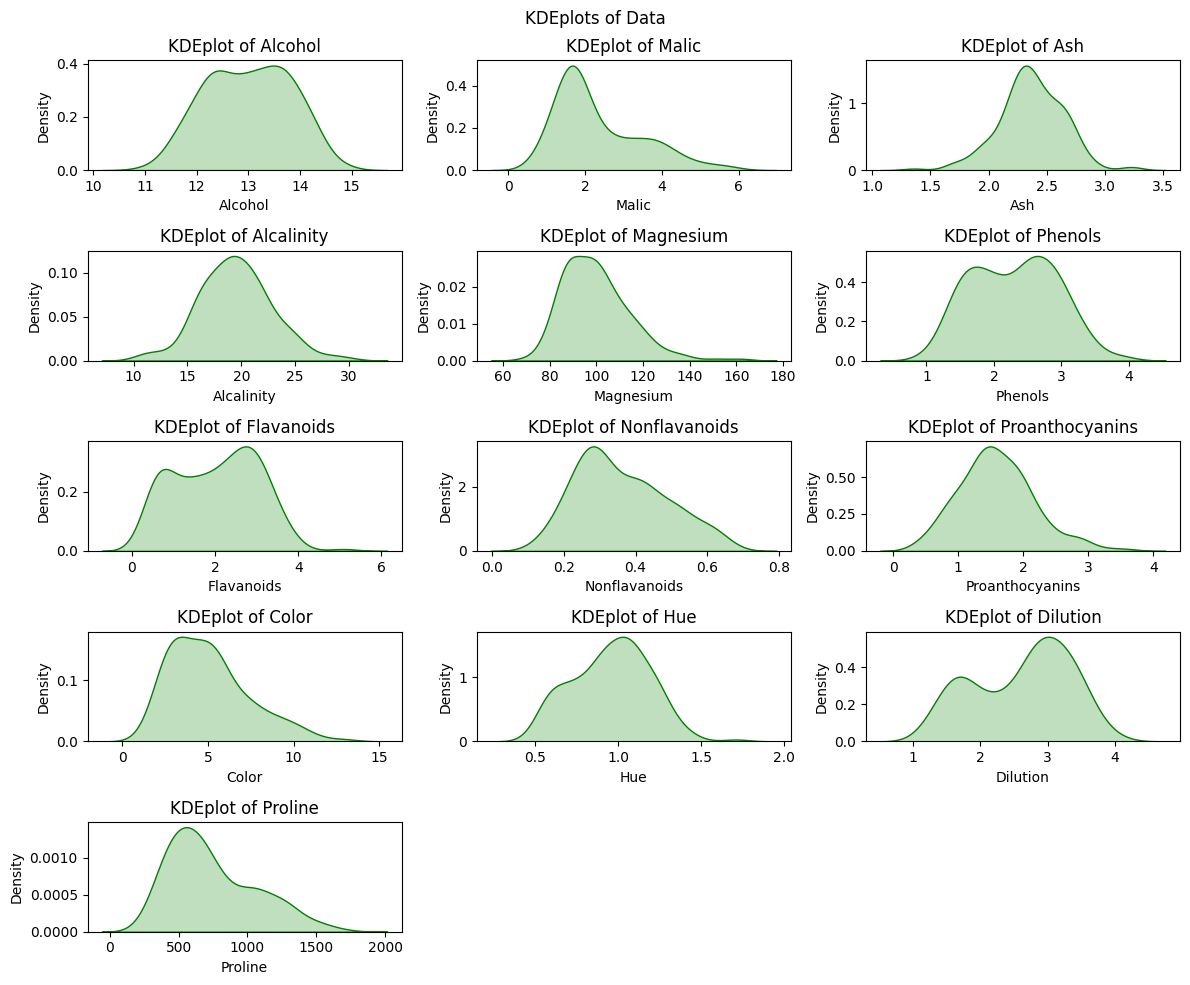

In [15]:
fig,ax = plt.subplots(5,3,figsize=(12,10))

for axis,col in zip(ax.flat,numerical_cols):
  sns.kdeplot(data = df,x=col,ax=axis,color="green",fill=True)
  axis.set_title(f"KDEplot of {col}")
  axis.set_xlabel(col)

for axis in ax.flat[len(numerical_cols):]:
  axis.remove()

plt.suptitle("KDEplots of Data")
plt.tight_layout()
plt.show()

### Observation :

The KDE plots provide a smoother view of the feature distributions.

- **Alcohol and Ash** show relatively symmetric distributions.
- **Malic, Magnesium, Color, and Proline** appear positively skewed.
- **Phenols, Flavanoids, and Dilution** show multiple density peaks, indicating possible multimodal distributions.
- The features have different distribution shapes and statistical characteristics.

## Correlation Matrix

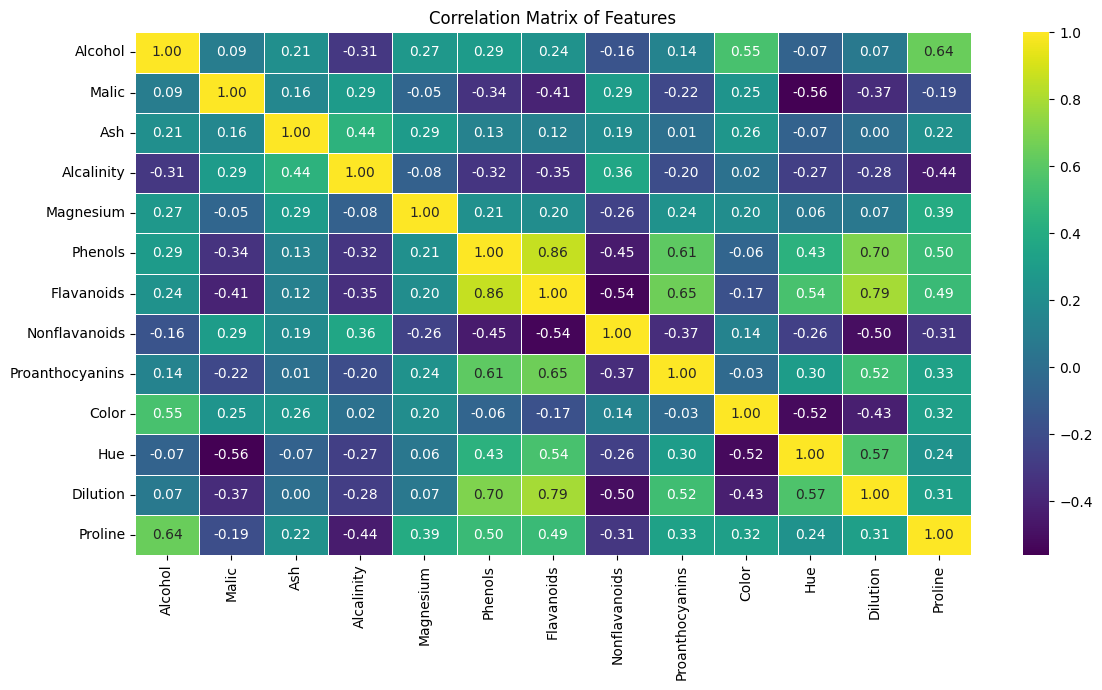

In [16]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    df.drop(columns="Type").corr(),
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="viridis"
)

plt.title("Correlation Matrix of Features")

plt.tight_layout()
plt.show()

### Observation :

The correlation matrix shows several meaningful relationships between the features.

### Strong Positive Correlations

- **Phenols ↔ Flavanoids:** `0.86`
- **Flavanoids ↔ Dilution:** `0.79`
- **Phenols ↔ Dilution:** `0.70`
- **Flavanoids ↔ Proanthocyanins:** `0.65`
- **Alcohol ↔ Proline:** `0.64`

### Strong Negative Correlations

- **Type ↔ Flavanoids:** `-0.85`
- **Type ↔ Dilution:** `-0.79`
- **Type ↔ Phenols:** `-0.72`

Several features show strong correlations, particularly **Phenols, Flavanoids, and Dilution**, indicating potential multicollinearity.

> **Note:** Since `Type` is a categorical target encoded as `1`, `2`, and `3`, its correlation values should be interpreted carefully.

# Data Preprocessing

## Feature and Target Separation

In [17]:
X = df.drop(columns = "Type")
y = df["Type"]

print("Feature Shape : ",X.shape)
print("Target Shape : ",y.shape)

Feature Shape :  (178, 13)
Target Shape :  (178,)


## Feature Scaling

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled,columns=X.columns)

X_scaled_df.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


## Checking Mean and Standard Deviation after Scaling

In [19]:
print("="*30)
print("Mean:")
print("="*30)
print(X_scaled_df.mean().round(2))
print("="*30)
print("Standard Deviation:")
print("="*30)
print(X_scaled_df.std().round(2))

Mean:
Alcohol           -0.0
Malic             -0.0
Ash               -0.0
Alcalinity        -0.0
Magnesium         -0.0
Phenols            0.0
Flavanoids        -0.0
Nonflavanoids      0.0
Proanthocyanins   -0.0
Color              0.0
Hue                0.0
Dilution           0.0
Proline           -0.0
dtype: float64
Standard Deviation:
Alcohol            1.0
Malic              1.0
Ash                1.0
Alcalinity         1.0
Magnesium          1.0
Phenols            1.0
Flavanoids         1.0
Nonflavanoids      1.0
Proanthocyanins    1.0
Color              1.0
Hue                1.0
Dilution           1.0
Proline            1.0
dtype: float64


# Observation :

The numerical features have significantly different scales and ranges. Therefore, the features were standardized using `StandardScaler` before applying PCA. Standardization ensures that each feature contributes equally to the PCA process and prevents variables with larger scales, such as `Proline`, from dominating the principal components.

# PCA

## Applying PCA

In [20]:
pca = PCA()

pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio : ")
print(explained_variance)

Explained Variance Ratio : 
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


## Creating PCA Explained Variance Table

In [21]:
pca_variance_df = pd.DataFrame({"Principal Component":[f"PC{i}" for i in range(1,len(explained_variance)+1)],
                                "Explained Variance":explained_variance,
                                "Cumulative Explained Variance":np.cumsum(explained_variance)})

pca_variance_df

,Principal Component,Explained Variance,Cumulative Explained Variance
0,PC1,0.361988,0.361988
1,PC2,0.192075,0.554063
2,PC3,0.111236,0.665300
3,PC4,0.070690,0.735990
4,PC5,0.065633,0.801623
5,PC6,0.049358,0.850981
6,PC7,0.042387,0.893368
7,PC8,0.026807,0.920175
8,PC9,0.022222,0.942397
9,PC10,0.019300,0.961697


## Scree Plot

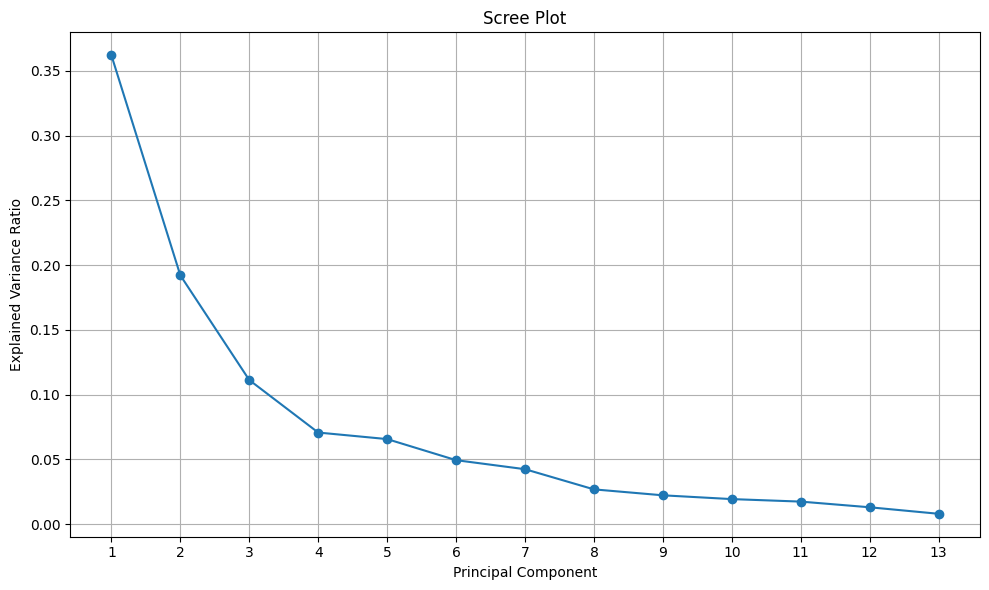

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.xticks(
    range(1, len(explained_variance) + 1)
)

plt.grid()

plt.tight_layout()
plt.show()

## Cumulative Variance Explained Plot

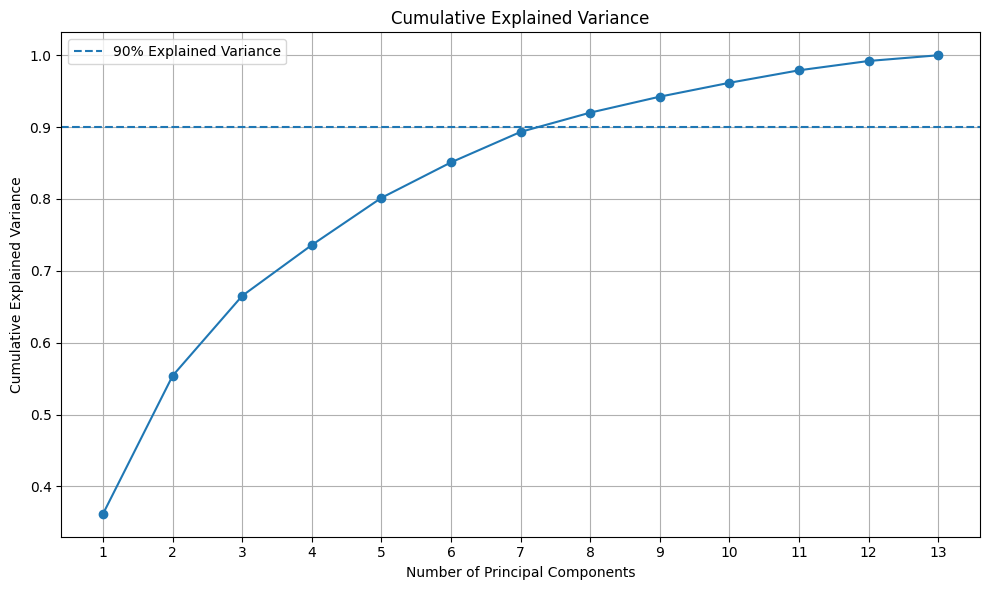

In [23]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% Explained Variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.xticks(
    range(1, len(cumulative_variance) + 1)
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Observation :

PCA was applied to the standardized feature set to reduce dimensionality while retaining the maximum possible information. The scree plot and cumulative explained variance plot help determine the optimal number of principal components.

The optimal number of components can be selected based on the point where the cumulative explained variance reaches an acceptable threshold, such as **90% or 95%**. Components beyond this point contribute relatively little additional information.

# Clustering

## K-Means

In [24]:
inertia = []

# Test different values of K
K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

## Plotting Elbow Curve

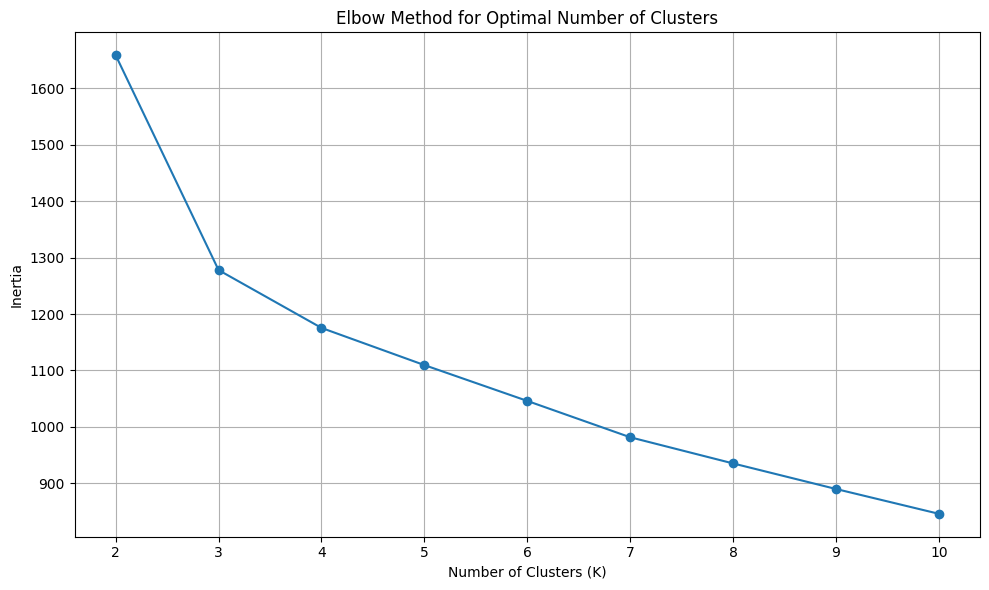

In [25]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.xticks(K_range)
plt.grid()

plt.tight_layout()
plt.show()

### Observation :

The Elbow Method was used to determine the optimal number of clusters for the original standardized dataset. The optimal value of **K** is identified at the point where the reduction in inertia begins to slow down significantly, forming an "elbow" in the curve.

## Calculating Silhoutte Scores

In [26]:
silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        cluster_labels
    )

    silhouette_scores.append(score)

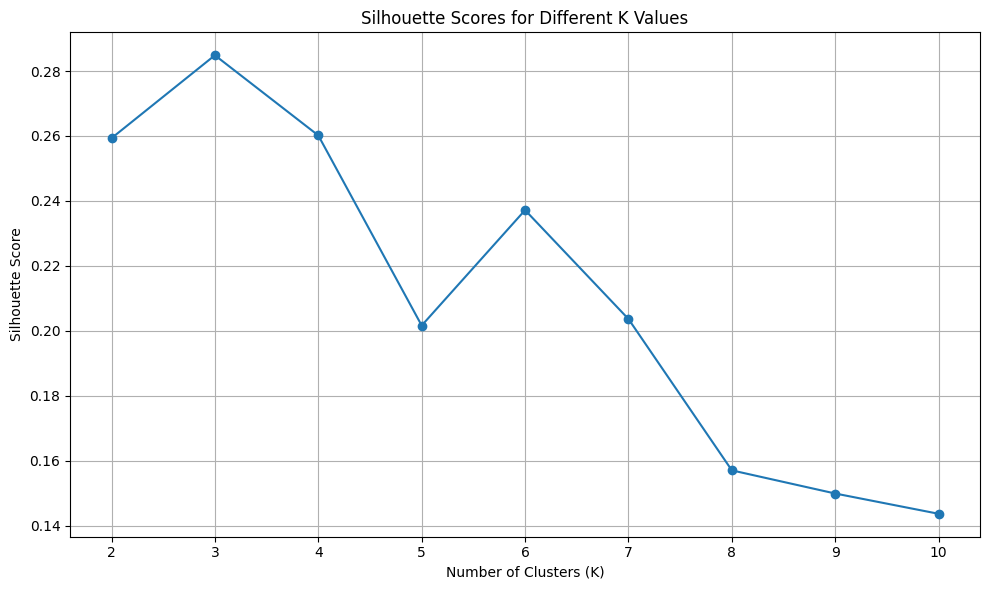

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different K Values")

plt.xticks(K_range)
plt.grid()

plt.tight_layout()
plt.show()

## Creating Clustering Results Table

In [28]:
clustering_results = pd.DataFrame({
    "Number of Clusters (K)": list(K_range),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

clustering_results

,Number of Clusters (K),Inertia,Silhouette Score
0,2,1658.758852,0.259317
1,3,1277.928489,0.284859
2,4,1175.428333,0.260170
3,5,1109.512739,0.201619
4,6,1046.002333,0.237167
5,7,981.595233,0.203628
6,8,935.201211,0.157014
7,9,889.892911,0.149882
8,10,845.895237,0.143638


## Choosing the Optimal K

In [29]:
optimal_k = 3

kmeans_original = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

original_clusters = kmeans_original.fit_predict(X_scaled)

## Evaluating Original Data Clustering

In [30]:
silhouette_original = silhouette_score(
    X_scaled,
    original_clusters
)

davies_bouldin_original = davies_bouldin_score(
    X_scaled,
    original_clusters
)

print(f"Silhouette Score: {silhouette_original:.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_original:.4f}")

Silhouette Score: 0.2849
Davies-Bouldin Score: 1.3892


## Visualizing Original Data Clusters

In [31]:
# Reduce data to 2 components for visualization

pca_visualization = PCA(n_components=2)

X_visual = pca_visualization.fit_transform(X_scaled)

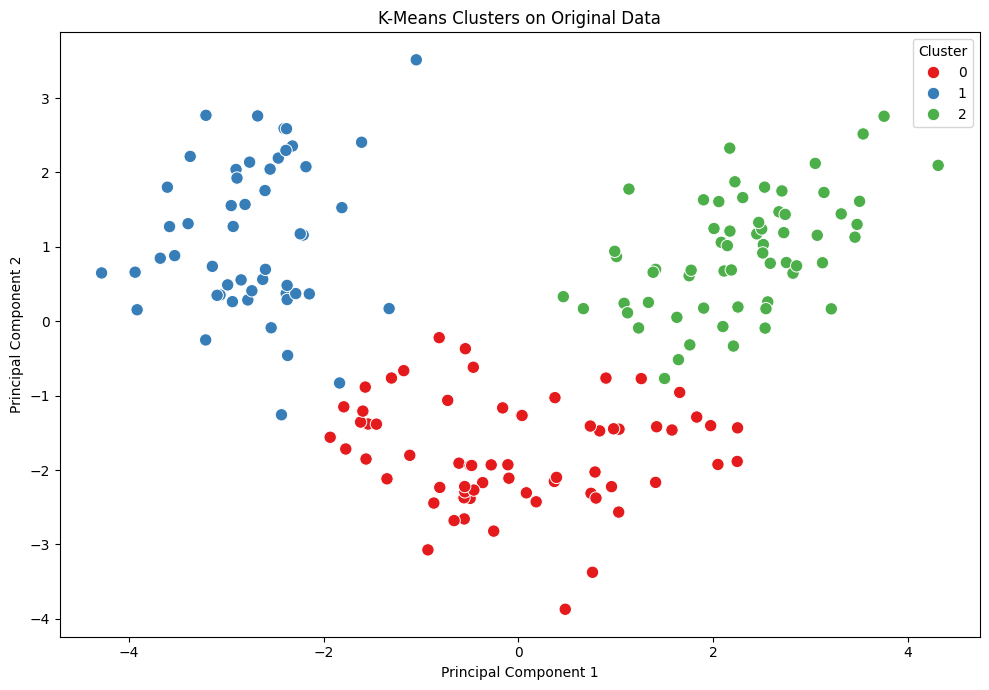

In [32]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_visual[:, 0],
    y=X_visual[:, 1],
    hue=original_clusters,
    palette="Set1",
    s=80
)

plt.title("K-Means Clusters on Original Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

## Observation :

K-Means clustering was applied to the original standardized dataset. The optimal number of clusters was selected using the Elbow Method and Silhouette Score analysis.

The clustering performance was evaluated using the **Silhouette Score** and **Davies-Bouldin Index**. The original dataset contains multiple dimensions, so PCA was used only to visualize the resulting clusters in two dimensions.

The evaluation metrics provide a baseline for comparing clustering performance after dimensionality reduction using PCA.

# Clustering with PCA Transformed Data

## PCA Component Selection Observation

**Observation:**

The cumulative explained variance analysis shows that the first **8 principal components retain approximately 92.02% of the total variance** in the dataset.

Therefore, **8 principal components were selected** for dimensionality reduction, as they retain more than the desired **90% explained variance** while reducing the original feature space from **13 dimensions to 8 dimensions**.

## Applying PCA with optimal Components

In [33]:
# Define the optimal number of components
optimal_components = 8

# Initialize PCA
pca_optimal = PCA(n_components=optimal_components)

# Transform the standardized data
X_pca = pca_optimal.fit_transform(X_scaled)

print("Original Data Shape:", X_scaled.shape)
print("PCA Data Shape:", X_pca.shape)

Original Data Shape: (178, 13)
PCA Data Shape: (178, 8)


## Checking Retained Variance

In [34]:
explained_variance_pca = pca_optimal.explained_variance_ratio_

cumulative_variance_pca = np.cumsum(explained_variance_pca)

print(
    f"Total Explained Variance: "
    f"{cumulative_variance_pca[-1]:.4f}"
)

Total Explained Variance: 0.9202


### Observation :

PCA was applied to the standardized dataset to reduce its dimensionality while retaining the maximum possible information. The original dataset containing **13 features** was reduced to a smaller number of principal components based on the cumulative explained variance criterion.

The selected principal components retain a substantial proportion of the total variance, allowing the dataset to be represented with fewer dimensions while minimizing information loss.

## Applying K-Means on PCA Data

In [35]:
# Apply K-Means clustering on PCA-transformed data

kmeans_pca = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

pca_clusters = kmeans_pca.fit_predict(X_pca)

## Evaluating PCA Clustering

In [36]:
silhouette_pca = silhouette_score(
    X_pca,
    pca_clusters
)

davies_bouldin_pca = davies_bouldin_score(
    X_pca,
    pca_clusters
)

print(f"Silhouette Score: {silhouette_pca:.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_pca:.4f}")

Silhouette Score: 0.3150
Davies-Bouldin Score: 1.2669


## Visualizing PCA Clusters

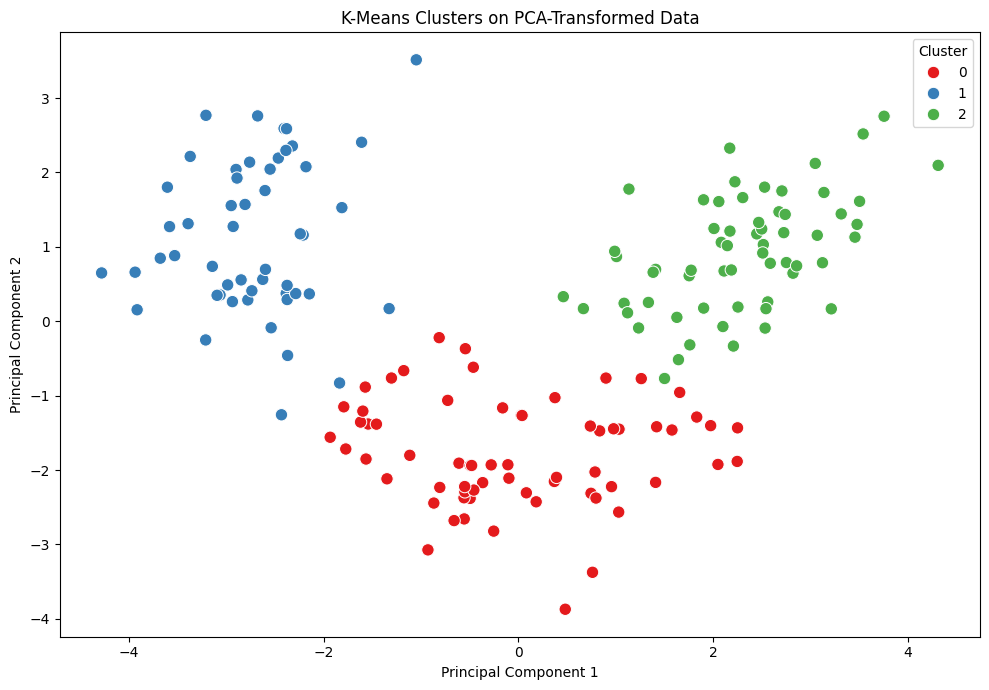

In [37]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=pca_clusters,
    palette="Set1",
    s=80
)

plt.title("K-Means Clusters on PCA-Transformed Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

## Observation :

K-Means clustering was applied to the PCA-transformed dataset using the same number of clusters as the original dataset. The clustering performance was evaluated using the **Silhouette Score** and **Davies-Bouldin Index**.

By reducing the dimensionality of the dataset, PCA simplifies the feature space while retaining most of the important information. The resulting evaluation metrics can be compared with those obtained from clustering the original standardized data to determine the impact of dimensionality reduction on clustering performance.

# COMPARISON

## Creating a Comparision Table

In [38]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Number of Dimensions",
        "Silhouette Score",
        "Davies-Bouldin Score"
    ],

    "Original Data": [
        X_scaled.shape[1],
        silhouette_original,
        davies_bouldin_original
    ],

    "PCA Data": [
        X_pca.shape[1],
        silhouette_pca,
        davies_bouldin_pca
    ]
})
comparison_df = comparison_df.round(4)
comparison_df

,Metric,Original Data,PCA Data
0,Number of Dimensions,13.0000,8.0000
1,Silhouette Score,0.2849,0.3150
2,Davies-Bouldin Score,1.3892,1.2669


### Observation :

The clustering results obtained from the original standardized dataset were compared with those obtained from the PCA-transformed dataset.

The original dataset contains **13 dimensions**, whereas PCA reduces the dataset to a smaller number of principal components while retaining most of the important information.

The **Silhouette Score** measures how well-separated and compact the clusters are, where a higher value indicates better clustering performance. The **Davies-Bouldin Score** measures cluster similarity, where a lower value indicates better clustering performance.

By comparing these metrics, we can determine whether dimensionality reduction using PCA improved, maintained, or reduced the clustering performance.

## Visual Comparision of Metrics

### Silhouette Score Comparison

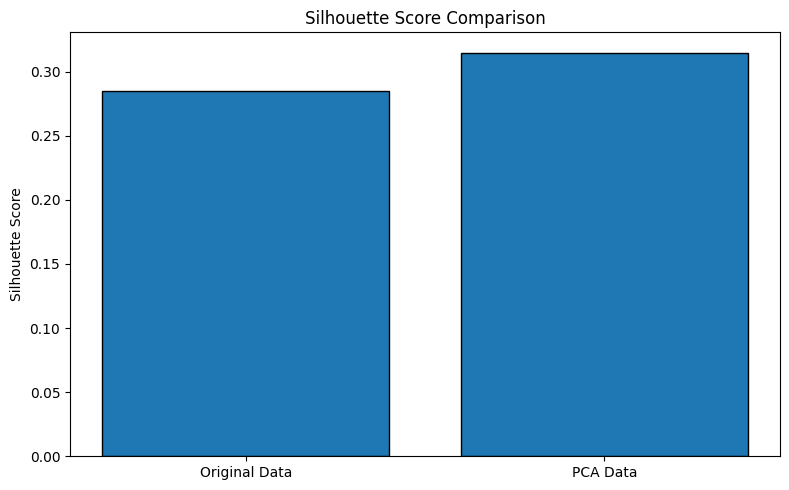

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Original Data", "PCA Data"],
    [silhouette_original, silhouette_pca],
    edgecolor="black"
)

plt.title("Silhouette Score Comparison")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

### Davies-Bouldin Score Comparison

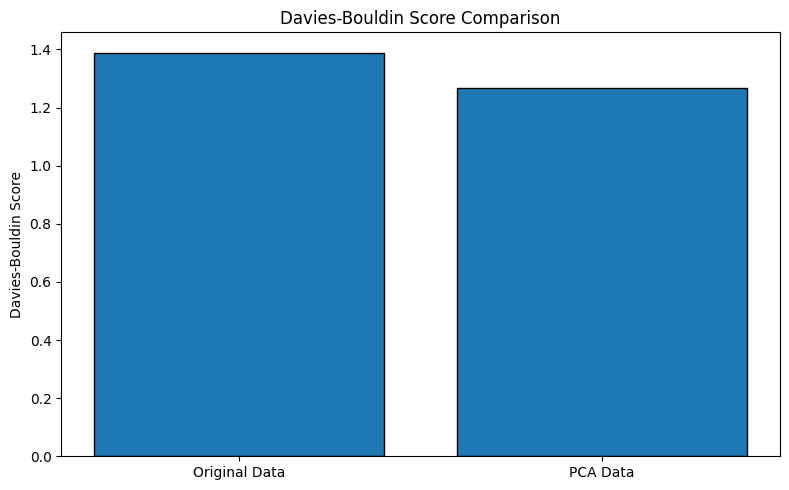

In [40]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Original Data", "PCA Data"],
    [davies_bouldin_original, davies_bouldin_pca],
    edgecolor="black"
)

plt.title("Davies-Bouldin Score Comparison")
plt.ylabel("Davies-Bouldin Score")

plt.tight_layout()
plt.show()

## Trade-off Analysis

### Advantages of Using PCA

- PCA reduces the number of dimensions in the dataset.
- It removes redundant information by combining correlated features.
- Reduced dimensionality can improve computational efficiency.
- PCA makes high-dimensional data easier to visualize and analyze.

### Limitations of Using PCA

- Some information is lost during dimensionality reduction.
- Principal components are less interpretable than the original features.
- PCA does not always improve clustering performance.
- Important feature-level information may be combined or lost.

### Overall Analysis

PCA provides a trade-off between **dimensionality reduction and information preservation**. If the clustering performance remains similar or improves after PCA, dimensionality reduction can be beneficial because it simplifies the dataset and reduces computational complexity. However, if clustering performance decreases significantly, using the original feature space may be more appropriate.

# Conclusion and Insights

## Conclusion

In this assignment, Exploratory Data Analysis (EDA), Principal Component Analysis (PCA), and K-Means clustering were applied to analyze the dataset and understand the impact of dimensionality reduction on clustering performance.

The EDA revealed that the dataset contains **178 observations and 13 numerical features**, with no missing values or duplicate records. The features showed different ranges and scales, making feature standardization necessary before applying PCA and K-Means clustering.

PCA was applied to the standardized dataset to reduce dimensionality while retaining most of the important information. The optimal number of principal components was selected based on the cumulative explained variance. This reduced the complexity of the dataset and provided a more compact representation of the original feature space.

K-Means clustering was then applied to both the original standardized dataset and the PCA-transformed dataset. The clustering performance was evaluated using the **Silhouette Score** and **Davies-Bouldin Index**.

The comparison between the original and PCA-transformed datasets demonstrates the trade-off between dimensionality reduction and clustering performance. PCA can reduce computational complexity and remove redundancy caused by correlated features. However, dimensionality reduction may also result in some loss of information and reduced interpretability.

## Key Insights

- The dataset was clean and contained no missing values or duplicate records.
- Feature standardization was necessary because the variables had significantly different scales.
- PCA successfully reduced the dimensionality of the dataset while retaining most of the important variance.
- K-Means clustering was performed on both the original and PCA-transformed datasets.
- The Silhouette Score and Davies-Bouldin Index were used to evaluate and compare clustering performance.
- PCA provides a balance between reducing dimensionality and preserving important information.

## Practical Recommendations

PCA is particularly useful when working with high-dimensional datasets containing correlated features. It can reduce computational requirements and simplify visualization while retaining a substantial amount of information.

Clustering directly on the original dataset may be preferred when preserving the interpretability of the original features is important. On the other hand, clustering after PCA can be beneficial when dimensionality reduction improves efficiency while maintaining similar clustering performance.

Therefore, the choice between clustering the original data and PCA-transformed data should be based on the balance between **clustering performance, computational efficiency, dimensionality, and interpretability**.